In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

### Column names are assigned

In [20]:
columns = ["engine_id", "time_cycles", "opr_setting_1", "opr_setting_2", "opr_setting_3"] + [f's{i}' for i in range(1,22)]
df = pd.read_csv('train_FD001.txt', sep='\s+', header=None, names=columns).dropna(axis = 1)
print(df.shape)
df.head

(20631, 26)


<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\elife\AppData\Local\Temp\ipykernel_13528\245124477.py:2: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv('train_FD001.txt', sep='\s+', header=None, names=columns).dropna(axis = 1)


<bound method NDFrame.head of        engine_id  time_cycles  opr_setting_1  opr_setting_2  opr_setting_3  \
0              1            1        -0.0007        -0.0004          100.0   
1              1            2         0.0019        -0.0003          100.0   
2              1            3        -0.0043         0.0003          100.0   
3              1            4         0.0007         0.0000          100.0   
4              1            5        -0.0019        -0.0002          100.0   
...          ...          ...            ...            ...            ...   
20626        100          196        -0.0004        -0.0003          100.0   
20627        100          197        -0.0016        -0.0005          100.0   
20628        100          198         0.0004         0.0000          100.0   
20629        100          199        -0.0011         0.0003          100.0   
20630        100          200        -0.0032        -0.0005          100.0   

           s1      s2       s3   

### Distributions of engine lives

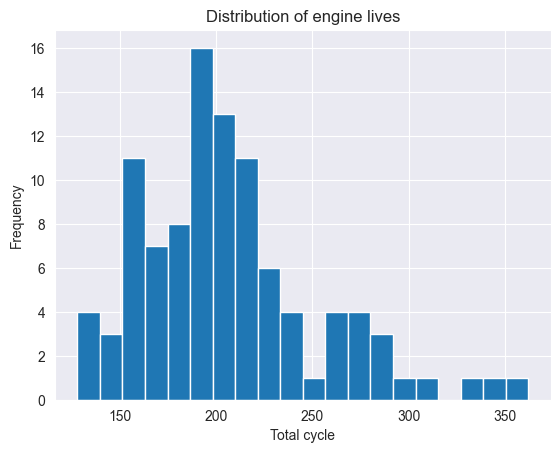

Average live: 206.31 cycle


In [23]:
engine_lives = df.groupby('engine_id')['time_cycles'].max()
engine_lives.hist(bins=20)
plt.xlabel('Total cycle'); plt.title('Distribution of engine lives'); plt.ylabel('Frequency') # Number of engines that failed during that flight
plt.show()
print(f"Average live: {engine_lives.mean():} cycle")

### Deleting sensors that are constans (Normalizing)

In [15]:
from sklearn.preprocessing import MinMaxScaler

# Varyansı sıfır olan sütunları at (bilgi taşımaz)
sensor_cols = [f's{i}' for i in range(1,22)]
low_var = df[sensor_cols].std() < 0.01
drop_cols = low_var[low_var].index.tolist()
df.drop(columns=drop_cols, inplace=True)

useful_sensors = [c for c in sensor_cols if c not in drop_cols]

scaler = MinMaxScaler()
df[useful_sensors] = scaler.fit_transform(df[useful_sensors])

In [17]:
df.shape

(20631, 19)